In [8]:
import os
import gc
import math
import random
import glob
from pathlib import Path

import cv2
import numpy as np
from PIL import Image

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import functional as TF
from torchvision.utils import make_grid,save_image

from tqdm.auto import tqdm

from transformers import CLIPTokenizer,CLIPTextModel
from diffusers import (
    AutoencoderKL,
    UNet2DConditionModel,
    ControlNetModel,
    DDPMScheduler,
    StableDiffusionControlNetPipeline,
    UniPCMultistepScheduler
)

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [10]:
SEED = 42

def seed_everything(seed=42):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

BASE_MODEL = 'runwayml/stable-diffusion-v1-5'
ROOT = Path('/content/celebhq_controlnet')
IMAGE_DIR = ROOT/'CelebA-HQ-img'
CONTROL_DIR = ROOT/'canny'
OUTPUT_DIR = ROOT/'controlnet_output'

IMAGE_DIR.mkdir(parents=True,exist_ok=True)
CONTROL_DIR.mkdir(parents=True,exist_ok=True)
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

RESOLUTION = 256
BATCH_SIZE = 1
GRAD_ACCUM_STEPS = 4
NUM_EPOCHS = 2
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-2
SAVE_EVERY = 1000
MAX_TRAIN_IMAGES = 1000

In [11]:
import kagglehub

DOWNLOAD_ROOT = Path("/content/celebhq_controlnet/CelebA-HQ-img")
DOWNLOAD_ROOT.mkdir(parents=True, exist_ok=True)

# Public Kaggle dataset
download_path = kagglehub.dataset_download(
    "ipythonx/celebamaskhq",
    output_dir=str(DOWNLOAD_ROOT),
)

print("Downloaded to:", download_path)

Downloaded to: /content/celebhq_controlnet/CelebA-HQ-img


In [12]:
IMAGE_DIR = Path("/content/celebhq_controlnet/CelebA-HQ-img/CelebAMask-HQ/CelebA-HQ-img")

In [13]:
image_paths = sorted(
    glob.glob(str(IMAGE_DIR/"*.jpg"))+
    glob.glob(str(IMAGE_DIR/"*.png"))+
    glob.glob(str(IMAGE_DIR/"*.jpeg"))
)

if MAX_TRAIN_IMAGES is not None:
  image_paths = image_paths[:MAX_TRAIN_IMAGES]

print("Images:",len(image_paths))
assert len(image_paths)>0

Images: 1000


In [14]:
def create_canny_image(path,output_path,low=100,high=200):
  image = cv2.imread(str(path))
  image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

  gray = cv2.cvtColor(image,cv2.COLOR_RGB2GRAY)
  edges = cv2.Canny(gray,low,high)

  edges = np.stack([edges,edges,edges],axis=-1)
  Image.fromarray(edges).save(output_path)

for path in tqdm(image_paths,desc='Creating Canny maps'):
  output_path = CONTROL_DIR/f"{Path(path).stem}.png"

  if not output_path.exists():
    create_canny_image(path,output_path)

print('Canny maps:',len(list(CONTROL_DIR.glob('*.png'))))

Creating Canny maps:   0%|          | 0/1000 [00:00<?, ?it/s]

Canny maps: 1650


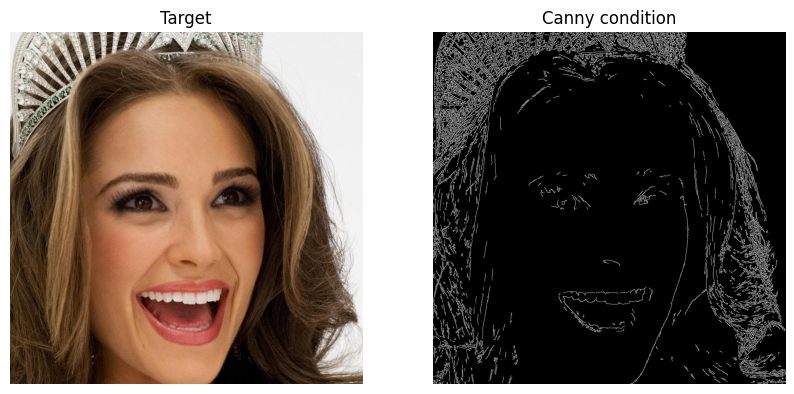

In [15]:
import matplotlib.pyplot as plt

sample_image = Image.open(image_paths[0]).convert('RGB')
sample_control = Image.open(CONTROL_DIR/f"{Path(image_paths[0]).stem}.png")

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(sample_image)
plt.axis('off')
plt.title('Target')

plt.subplot(1,2,2)
plt.imshow(sample_control)
plt.axis(False)
plt.title('Canny condition')
plt.show()

In [17]:
class CelebHQControlDataset(Dataset):
  def __init__(
      self,
      image_paths,
      control_dir,
      resolution=256,
      prompt='high quality studio portrait photograph of a person',
  ):

    self.image_paths = image_paths
    self.control_dir = Path(control_dir)
    self.resolution = resolution
    self.prompt = prompt

  def __len__(self):
    return len(self.image_paths)

  def _load_rgb(self,path):
    return Image.open(path).convert('RGB')

  def __getitem__(self, index):
    image_path = self.image_paths[index]
    image = self._load_rgb(image_path)

    control_path = self.control_dir/f"{Path(image_path).stem}.png"
    control = self._load_rgb(control_path)

    image = TF.resize(
        image,
        [self.resolution,self.resolution],
        interpolation=TF.InterpolationMode.BILINEAR,
    )

    control = TF.resize(
        control,
        [self.resolution,self.resolution],
        interpolation=TF.InterpolationMode.NEAREST,
    )

    if random.random() < 0.5:
      image = TF.hflip(image)
      control = TF.hflip(control)


    image = TF.to_tensor(image)
    image = image * 2.0 - 1.0

    control = TF.to_tensor(control)
    control = control * 2.0 - 1.0

    return {
        'pixel_values': image,
        'conditioning_pixel_values': control,
        'prompt': self.prompt
    }

In [18]:
dataset = CelebHQControlDataset(
    image_paths = image_paths,
    control_dir = CONTROL_DIR,
    resolution = RESOLUTION,
)

loader = DataLoader(
    dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers=2,
    pin_memory=2,
    drop_last=True,
)

batch = next(iter(loader))
print(batch['pixel_values'].shape)
print(batch['conditioning_pixel_values'].shape)


torch.Size([1, 3, 256, 256])
torch.Size([1, 3, 256, 256])


In [19]:
dtype = torch.float16

tokenizer = CLIPTokenizer.from_pretrained(
    BASE_MODEL,
    subfolder='tokenizer',
)

text_encoder = CLIPTextModel.from_pretrained(
    BASE_MODEL,
    subfolder='text_encoder',
    torch_dtype=dtype,
).to(device)

vae = AutoencoderKL.from_pretrained(
    BASE_MODEL,
    subfolder='vae',
    torch_dtype=dtype,
).to(device)

unet = UNet2DConditionModel.from_pretrained(
    BASE_MODEL,
    subfolder='unet',
    torch_dtype=dtype,
).to(device)

noise_encoder = DDPMScheduler.from_pretrained(
    BASE_MODEL,
    subfolder='scheduler',
)

text_encoder.requires_grad_(False)
vae.requires_grad_(False)
unet.requires_grad_(False)

text_encoder.eval()
vae.eval()
unet.eval()

print('Loaded frozen SD 1.5 backbone')

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 3.44GB            

unet/diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

Loaded frozen SD 1.5 backbone


In [31]:
controlnet = ControlNetModel.from_unet(
    unet,
    load_weights_from_unet=True,
)

controlnet = controlnet.to(device)
controlnet.train()

controlnet.enable_gradient_checkpointing()

In [32]:
try:
  controlnet.enable_xformers_memory_efficient_attention()
  unet.enable_xformers_memory_efficient_attention()
  print('xFormers attention enabled')

except Exception as e:
  print('xFormers unavailable:',str(e))

xFormers unavailable: Refer to https://github.com/facebookresearch/xformers for more information on how to install xformers


In [33]:
trainable_params = sum(
    p.numel() for p in controlnet.parameters() if p.requires_grad
)

frozen_params = sum(
    p.numel()
    for model in [vae,text_encoder,unet]
    for p in model.parameters()
)

print(f"Trainable ControlNet parameters: {trainable_params/1e6:.2f}M")
print(f"Frozen backbone parameters: {frozen_params/1e6:.2f}M")

Trainable ControlNet parameters: 361.28M
Frozen backbone parameters: 1066.24M


In [34]:
PROMPT = 'high quality studio portrait photograph of a person'

tokens = tokenizer(
    PROMPT,
    max_length=tokenizer.model_max_length,
    padding='max_length',
    truncation=True,
    return_tensors='pt',
)

with torch.no_grad():
  encoder_hidden_states = text_encoder(
      tokens.input_ids.to(device)
  )[0]

encoder_hidden_states = encoder_hidden_states.to(dtype=dtype)

print(encoder_hidden_states.shape)

torch.Size([1, 77, 768])


In [35]:
PROMPTS = [
    "high quality studio portrait photograph of a person",
    "professional editorial portrait photograph",
    "close-up realistic human face, soft cinematic lighting",
    "fashion portrait photograph, detailed facial features",
]

In [36]:
try:
  import bitsandbytes as bnb

  optimizer = bnb.optim.AdamW8bit(
      controlnet.parameters(),
      lr=LEARNING_RATE,
      betas=(0.9,0.999),
      weight_decay=WEIGHT_DECAY,
  )
  print('Using 8-bit AdamW optimizer')

except Exception:
  optimizer = torch.optim.AdamW(
      controlnet.parameters(),
      lr=LEARNING_RATE,
      betas=(0.9,0.999),
      weight_decay=WEIGHT_DECAY,
  )
  print('Using standard AdamW')

lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS*math.ceil(len(loader)/GRAD_ACCUM_STEPS),
    eta_min=LEARNING_RATE*0.1,
)

Using standard AdamW


In [37]:
scaler = torch.amp.GradScaler('cuda', enabled=True)

global_step = 0
optimizer.zero_grad(set_to_none=True)

for epoch in range(NUM_EPOCHS):
  progress = tqdm(loader,desc=f"Epoch {epoch +1}/{NUM_EPOCHS}")

  for step,batch in enumerate(progress):
    pixel_values = batch['pixel_values'].to(
        device,dtype=dtype,non_blocking=True
    )

    conditioning = batch['conditioning_pixel_values'].to(
        device, dtype=dtype,non_blocking=True
    )

    with torch.no_grad():
      latents = vae.encode(pixel_values).latent_dist.sample()
      latents = latents*vae.config.scaling_factor

    noise = torch.randn_like(latents)

    timesteps = torch.randint(
        0,
        noise_encoder.config.num_train_timesteps,
        (latents.shape[0],),
        device=device,
    ).long()

    noisy_latents = noise_encoder.add_noise(
        latents,
        noise,
        timesteps,
    )

    with torch.autocast(
        device_type='cuda',
        dtype=torch.float16,
    ):

      down_block_res_samples, mid_block_res_sample = controlnet(
          noisy_latents,
          timesteps,
          encoder_hidden_states=encoder_hidden_states.repeat(
              latents.shape[0],1,1
          ),
          controlnet_cond = conditioning,
          conditioning_scale=1.0,
          return_dict=False,
      )

      model_pred = unet(
          noisy_latents,
          timesteps,
          encoder_hidden_states=encoder_hidden_states.repeat(
              latents.shape[0],1,1
          ),
          down_block_additional_residuals=down_block_res_samples,
          mid_block_additional_residual=mid_block_res_sample,
      )[0]

      loss = F.mse_loss(model_pred.float(),noise.float())
      loss = loss/GRAD_ACCUM_STEPS

    scaler.scale(loss).backward()

    if (step+1)%GRAD_ACCUM_STEPS == 0:
      scaler.unscale_(optimizer)

      torch.nn.utils.clip_grad_norm_(
          controlnet.parameters(),
          max_norm=1.0,
      )

      scaler.step(optimizer)
      scaler.update()
      optimizer.zero_grad(set_to_none=True)

      lr_scheduler.step()
      global_step +=1

      if global_step % 25 == 0:
        progress.set_postfix(
            loss=float(loss.item()*GRAD_ACCUM_STEPS),
            lr=lr_scheduler.get_last_lr()[0],
        )

      if global_step % SAVE_EVERY == 0:
        checkpoint_path = OUTPUT_DIR / f"controlnet_step_{global_step}"
        controlnet.save_pretrained(checkpoint_path)
        print(f"\nSaved checkpoint: {checkpoint_path}")

    del (
        pixel_values,
        conditioning,
        latents,
        noise,
        noisy_latents,
        down_block_res_samples,
        mid_block_res_sample,
        model_pred,
    )

  checkpoint_path = OUTPUT_DIR / f"controlnet_epoch_{epoch+1}"
  controlnet.save_pretrained(checkpoint_path)
  print(f"\nSaved epoch checkpoint: {checkpoint_path}")


  gc.collect()
  torch.cuda.empty_cache()

Epoch 1/2:   0%|          | 0/1000 [00:00<?, ?it/s]


Saved epoch checkpoint: /content/celebhq_controlnet/controlnet_output/controlnet_epoch_1


Epoch 2/2:   0%|          | 0/1000 [00:00<?, ?it/s]


Saved epoch checkpoint: /content/celebhq_controlnet/controlnet_output/controlnet_epoch_2


In [38]:
FINAL_CONTROLNET = OUTPUT_DIR / "controlnet_final"
controlnet.save_pretrained(FINAL_CONTROLNET)

print("Saved:", FINAL_CONTROLNET)

Saved: /content/celebhq_controlnet/controlnet_output/controlnet_final


In [39]:
import json

config = {
    "base_model": BASE_MODEL,
    "resolution": RESOLUTION,
    "condition": "canny",
    "batch_size": BATCH_SIZE,
    "gradient_accumulation_steps": GRAD_ACCUM_STEPS,
    "learning_rate": LEARNING_RATE,
    "epochs": NUM_EPOCHS,
    "prompt": PROMPT,
}

with open(OUTPUT_DIR / "training_config.json", "w") as f:
    json.dump(config, f, indent=2)

In [40]:
del optimizer
del lr_scheduler
del scaler
del controlnet
del unet
del vae
del text_encoder

gc.collect()
torch.cuda.empty_cache()

In [41]:
trained_controlnet = ControlNetModel.from_pretrained(
    FINAL_CONTROLNET,
    torch_dtype=torch.float16,
).to(device)

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    BASE_MODEL,
    controlnet=trained_controlnet,
    torch_dtype=torch.float16,
    safety_checker=None,
).to(device)

pipe.scheduler = UniPCMultistepScheduler.from_config(
    pipe.scheduler.config
)

pipe.enable_attention_slicing()
pipe.enable_vae_slicing()

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2273: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionControlNetPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`

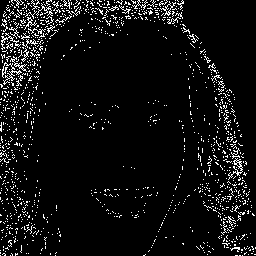

In [42]:
source_path = image_paths[0]
control_path = CONTROL_DIR / f"{Path(source_path).stem}.png"

control_image = Image.open(control_path).convert("RGB")
control_image = control_image.resize(
    (RESOLUTION, RESOLUTION),
    Image.Resampling.NEAREST,
)

display(control_image)

  0%|          | 0/30 [00:00<?, ?it/s]

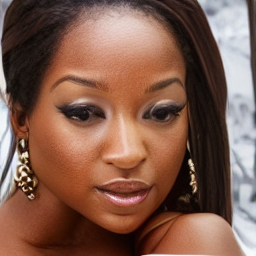

In [43]:
generator = torch.Generator(device=device).manual_seed(1234)

result = pipe(
    prompt=(
        "high quality realistic studio portrait photograph, "
        "detailed face, natural skin texture, cinematic lighting"
    ),
    negative_prompt=(
        "low quality, blurry, distorted face, deformed eyes, "
        "duplicate face, bad anatomy, artifacts"
    ),
    image=control_image,
    num_inference_steps=30,
    guidance_scale=7.0,
    controlnet_conditioning_scale=1.2,
    generator=generator,
    height=RESOLUTION,
    width=RESOLUTION,
).images[0]

display(result)
result.save(OUTPUT_DIR / "generated_face.png")

  0%|          | 0/30 [00:00<?, ?it/s]

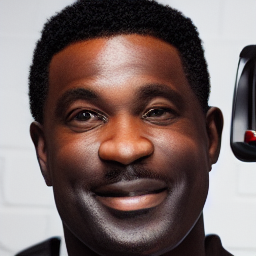

  0%|          | 0/30 [00:00<?, ?it/s]

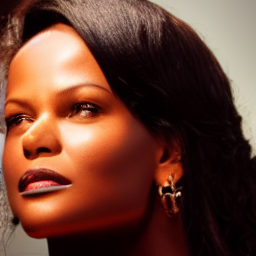

  0%|          | 0/30 [00:00<?, ?it/s]

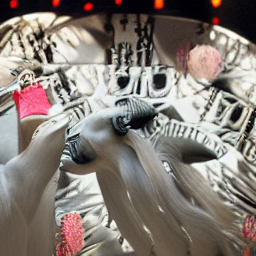

  0%|          | 0/30 [00:00<?, ?it/s]

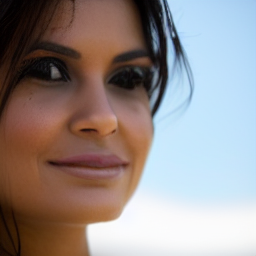

In [44]:
prompts = [
    "realistic professional headshot, soft studio lighting",
    "cinematic portrait, dramatic rim lighting, detailed face",
    "editorial fashion portrait, high-end photography",
    "natural outdoor portrait, shallow depth of field",
]

for i, prompt in enumerate(prompts):
    generator = torch.Generator(device=device).manual_seed(1000 + i)

    image = pipe(
        prompt=prompt,
        negative_prompt=(
            "low quality, blurry, distorted face, malformed eyes, "
            "duplicate person, bad anatomy"
        ),
        image=control_image,
        num_inference_steps=30,
        guidance_scale=7.0,
        controlnet_conditioning_scale=1.0,
        generator=generator,
        height=RESOLUTION,
        width=RESOLUTION,
    ).images[0]

    image.save(OUTPUT_DIR / f"generated_{i:02d}.png")
    display(image)